In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [45]:
#Team eco
df_team_eco = pd.read_csv("./tables/table_team_economy.csv")

<Axes: >

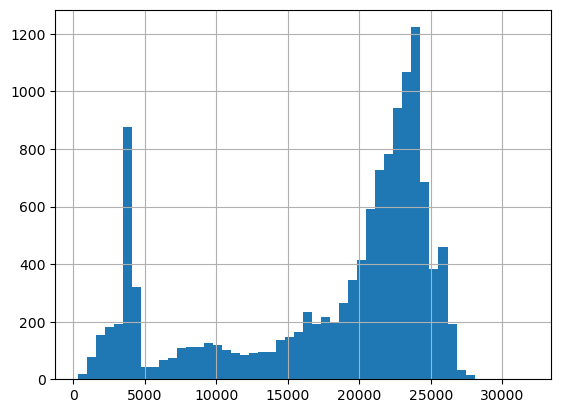

In [46]:
df_buys = pd.concat([df_team_eco["team_a_economy"],df_team_eco["team_b_economy"]],ignore_index=True)
df_buys.hist(bins=50)

In [42]:
df_team_eco.groupby("team_a_economy").sum()

,team_a,team_b,team_b_economy,round,team_a_bank,team_b_bank,map,date,source_url,event,series_id,map_id,reg_id,tour_id,team_map_round_id,eco_dif
team_a_economy,,,,,,,,,,,,,,,,
450,T1,PRX,16450,2,10400,2900,Pearl,2026-02-06 06:00:00,https://www.vlr.gg/595648/paper-rex-vs-t1-vct-...,VCT 2026: Pacific Kickoff,595648,595648-Pearl,reg_3,vct_2026_pacific_kickoff,PRX-T1-595648-Pearl-2,16000
600,FNCKC,FUTTH,33650,4,18900,6800,SplitAbyss,2026-01-27 14:20:002026-02-05 11:00:00,https://www.vlr.gg/594752/fut-esports-vs-fnati...,VCT 2026: EMEA KickoffVCT 2026: EMEA Kickoff,1189515,594752-Split594763-Abyss,reg_1reg_1,vct_2026_emea_kickoffvct_2026_emea_kickoff,FNC-FUT-594752-Split-2KC-TH-594763-Abyss-2,32450
650,VIT,ULF,15750,2,10000,2200,Corrode,2026-01-21 14:20:00,https://www.vlr.gg/594743/ulf-esports-vs-team-...,VCT 2026: EMEA Kickoff,594743,594743-Corrode,reg_1,vct_2026_emea_kickoff,ULF-VIT-594743-Corrode-2,15100
700,C9,LOUD,16600,2,10100,1300,Haven,2026-01-15 20:10:00,https://www.vlr.gg/596398/loud-vs-cloud9-vct-2...,VCT 2026: Americas Kickoff,596398,596398-Haven,reg_0,vct_2026_americas_kickoff,C9-LOUD-596398-Haven-2,15900
750,M8FNC,FUTFUT,30150,4,19400,9400,AbyssAbyss,2026-01-20 13:35:002026-01-27 14:20:00,https://www.vlr.gg/594741/fut-esports-vs-gentl...,VCT 2026: EMEA KickoffVCT 2026: EMEA Kickoff,1189493,594741-Abyss594752-Abyss,reg_1reg_1,vct_2026_emea_kickoffvct_2026_emea_kickoff,FUT-M8-594741-Abyss-2FNC-FUT-594752-Abyss-2,28650
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27550,G2EG,FURLOUD,43550,24,24300,3000,BindAbyss,2026-01-30 20:55:002026-01-31 17:00:00,https://www.vlr.gg/596407/furia-vs-g2-esports-...,VCT 2026: Americas KickoffVCT 2026: Americas K...,1192826,596407-Bind596419-Abyss,reg_0reg_0,vct_2026_americas_kickoffvct_2026_americas_kic...,FUR-G2-596407-Bind-12EG-LOUD-596419-Abyss-12,11550
27600,C9,ENVY,17350,11,28300,3900,Pearl,2026-01-25 20:00:00,https://www.vlr.gg/596414/envy-vs-cloud9-vct-2...,VCT 2026: Americas Kickoff,596414,596414-Pearl,reg_0,vct_2026_americas_kickoff,C9-ENVY-596414-Pearl-11,10250
27700,BBL,FUR,10750,11,13200,7900,Breeze,2026-03-08 13:00:00,https://www.vlr.gg/626546/furia-vs-bbl-esports...,Valorant Masters Santiago 2026,626546,626546-Breeze,reg_4,valorant_masters_santiago_2026,BBL-FUR-626546-Breeze-11,16950


In [38]:
df_buys.groupby().count()

TypeError: You have to supply one of 'by' and 'level'

<Axes: >

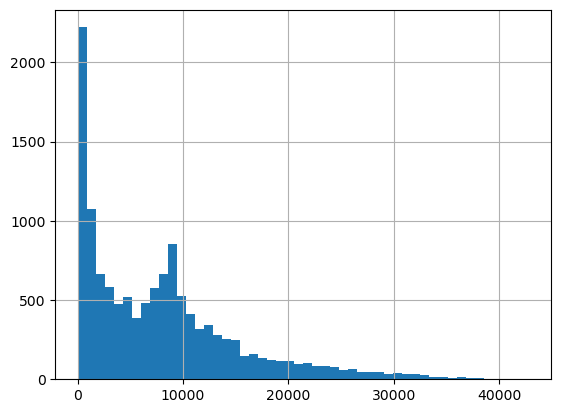

In [44]:
df_bank = pd.concat([df_team_eco["team_a_bank"],df_team_eco["team_b_bank"]],ignore_index=True)
df_bank.hist(bins=50)

In [11]:
df_team_eco["eco_dif"] = np.where(df_team_eco["team_a_economy"]-df_team_eco["team_b_economy"] >= 0, df_team_eco["team_a_economy"]-df_team_eco["team_b_economy"],df_team_eco["team_b_economy"]-df_team_eco["team_a_economy"] )

<Axes: >

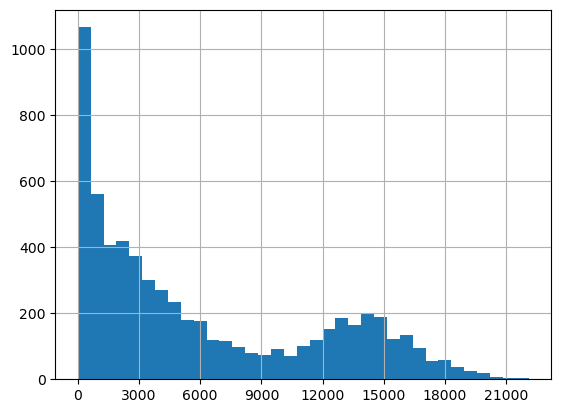

In [24]:
plt.xticks([x for x in range(0,25000,3000)])
df_team_eco["eco_dif"].hist(bins=35)

<Axes: >

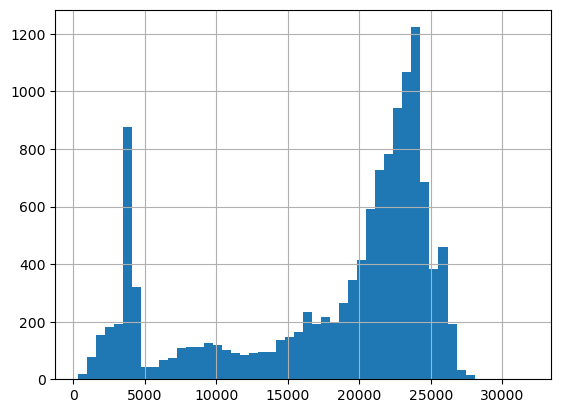

In [76]:
df_round_detail = pd.read_csv("rndDetail.csv")
sort_columns = ["date","map_order","round"]
df_round_detail_sorted = df_round_detail.sort_values(by=sort_columns).reset_index(drop=True)

df_concat = None

for date in df_round_detail_sorted["date"].unique():
    for map in df_round_detail_sorted["map_order"].unique():
        df_round_sorted_filter_date = df_round_detail_sorted["date"] == date
        df_round_sorted_filter_map = df_round_detail_sorted["map_order"] == map
        df_round_detail_sorted["teamA_cumRnd"] = df_round_detail_sorted[df_round_sorted_filter_date & df_round_sorted_filter_map]["rndA"].cumsum(axis=0)
        df_round_detail_sorted["teamB_cumRnd"] = df_round_detail_sorted[df_round_sorted_filter_date & df_round_sorted_filter_map]["rndB"].cumsum(axis=0)        
        #get max
        team_a_max = df_round_detail_sorted["teamA_cumRnd"].max()
        team_b_max = df_round_detail_sorted["teamB_cumRnd"].max()
        #add winner 
        if team_b_max > team_a_max:
            df_round_detail_sorted["winner"] = "Team B"
        elif team_b_max < team_a_max:
            df_round_detail_sorted["winner"] = "Team A"
        
        
        if df_concat is None:
            df_concat = df_round_detail_sorted.dropna()
        else:
            df_concat = pd.concat([df_concat,df_round_detail_sorted.dropna()]) 
            
#change format
df_concat["teamA_cumRnd"] = df_concat["teamA_cumRnd"].apply(lambda x: int(x))
df_concat["teamB_cumRnd"] = df_concat["teamB_cumRnd"].apply(lambda x: int(x)) 

#Add partial scores: Team A score - Team B score
df_concat["partial_score"] =  df_concat["teamA_cumRnd"].apply(lambda x: str(x)) + "-" + df_concat["teamB_cumRnd"].apply(lambda x: str(x))
df_concat["difference"] = df_concat["teamA_cumRnd"] - df_concat["teamB_cumRnd"]

In [77]:
sort_columns_concat = ["date","map_order","round"]
df_concat = df_concat.sort_values(by=sort_columns).reset_index(drop=True)

In [78]:
df_concat["comeback"] = np.where((df_concat["difference"] < 0) & (df_concat["winner"] == "Team A") | 
                                (df_concat["difference"] > 0) & (df_concat["winner"] == "Team B")
                                , 1, 0 )

In [ ]:
#combacks registrados: 

df_concat[df_concat["comeback"] == 1]

#seguimiento de comebakcs: 1 por id unica

tracking_id_date = None
tracking_id_map = None
tracking_max_dif_teamA = None

,teamA,map,side,teamB,rndA,rndB,round,winCon,date,map_order,event,teamA_cumRnd,teamB_cumRnd,winner,partial_score,difference,comeback
22,Team Heretics,Icebox,Atk,Paper Rex,1,0,9,elim,2025-06-07 12:00:00,1,Valorant Masters Toronto 2025,5,4,Team B,5-4,1,1
24,Team Heretics,Icebox,Atk,Paper Rex,1,0,11,elim,2025-06-07 12:00:00,1,Valorant Masters Toronto 2025,6,5,Team B,6-5,1,1
25,Team Heretics,Icebox,Atk,Paper Rex,1,0,12,elim,2025-06-07 12:00:00,1,Valorant Masters Toronto 2025,7,5,Team B,7-5,2,1
26,Team Heretics,Icebox,Def,Paper Rex,0,1,13,elim,2025-06-07 12:00:00,1,Valorant Masters Toronto 2025,7,6,Team B,7-6,1,1
40,Bilibili Gaming,Icebox,Def,Team Liquid,0,1,5,boom,2025-06-07 14:10:00,0,Valorant Masters Toronto 2025,2,3,Team A,2-3,-1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
984,Sentinels,Icebox,Atk,FNATIC,1,0,10,elim,2025-06-17 15:35:00,2,Valorant Masters Toronto 2025,6,4,Team B,6-4,2,1
985,Sentinels,Icebox,Atk,FNATIC,0,1,11,elim,2025-06-17 15:35:00,2,Valorant Masters Toronto 2025,6,5,Team B,6-5,1,1
986,Sentinels,Icebox,Atk,FNATIC,1,0,12,elim,2025-06-17 15:35:00,2,Valorant Masters Toronto 2025,7,5,Team B,7-5,2,1
987,Sentinels,Icebox,Def,FNATIC,0,1,13,elim,2025-06-17 15:35:00,2,Valorant Masters Toronto 2025,7,6,Team B,7-6,1,1


In [ ]:
save_values = {"round_dif":[],"date":[]}

def save_comebacks_date_map(df):
    values =  np.where((df_concat["difference"] < 0) & (df_concat["winner"] == "Team A") | 
                                (df_concat["difference"] > 0) & (df_concat["winner"] == "Team B")
                                , True, False )
    if values == True:

     

['No comeback' 'No comeback' 'No comeback' 'No comeback' 'No comeback'
 'No comeback' 'No comeback' 'No comeback' 'No comeback' 'No comeback'
 'No comeback' 'No comeback' 'No comeback' 'No comeback' 'No comeback'
 'No comeback' 'No comeback' 'No comeback' 'No comeback' 'No comeback'
 'No comeback' 'No comeback' 'comeback' 'No comeback' 'comeback'
 'comeback' 'comeback' 'No comeback' 'No comeback' 'No comeback'
 'No comeback' 'No comeback' 'No comeback' 'No comeback' 'No comeback'
 'No comeback' 'No comeback' 'No comeback' 'No comeback' 'No comeback'
 'comeback' 'No comeback' 'comeback' 'comeback' 'comeback' 'comeback'
 'comeback' 'comeback' 'comeback' 'No comeback' 'comeback' 'No comeback'
 'No comeback' 'No comeback' 'No comeback' 'No comeback' 'No comeback'
 'No comeback' 'No comeback' 'No comeback' 'No comeback' 'No comeback'
 'No comeback' 'comeback' 'No comeback' 'comeback' 'comeback' 'comeback'
 'comeback' 'comeback' 'comeback' 'comeback' 'comeback' 'comeback'
 'comeback' 'comeba

In [ ]:
df_concat_winners = None

for date in df_concat["date"].unique():
    for map in df_concat["map_order"].unique():
        df_round_sorted_filter_date = df_concat["date"] == date
        df_round_sorted_filter_map = df_concat["map_order"] == map
        #get max and min

        df_concat["max_diff_a"] = df_concat[df_round_sorted_filter_date & df_round_sorted_filter_map]["difference"].max()
        df_concat["max_diff_b"] = df_concat[df_round_sorted_filter_date & df_round_sorted_filter_map]["difference"].min()

        if df_concat_winners is None:
            df_concat_winners = df_concat.dropna()
        else:
            df_concat_winners = pd.concat([df_concat_winners,df_concat.dropna()]) 

# #change format
# df_concat_winners["max_diff_a"] = df_concat_winners["max_diff_a"].apply(lambda x: int(x))
# df_concat_winners["max_diff_b"] = df_concat_winners["max_diff_b"].apply(lambda x: int(x)) 
        

997
997
0
997
997
997
997
997
0
997
997
0
997
997
997
997
997
0
997
997
0
997
997
0
997
997
0
997
997
997
997
997
0
997
997
0
997
997
0
997
997
997
997
997
0
997
997
997
997
997
0
997
997
0
997
997
997
997
997
997


In [91]:
df_concat_winners


,teamA,map,side,teamB,rndA,rndB,round,winCon,date,map_order,event,teamA_cumRnd,teamB_cumRnd,winner,partial_score,difference,max_diff_a,max_diff_b
0,Team Heretics,Pearl,Def,Paper Rex,0,1,1,elim,2025-06-07 12:00:00,0,Valorant Masters Toronto 2025,0,1,Team B,0-1,-1,-1.0,-12.0
1,Team Heretics,Pearl,Def,Paper Rex,0,1,2,boom,2025-06-07 12:00:00,0,Valorant Masters Toronto 2025,0,2,Team B,0-2,-2,-1.0,-12.0
2,Team Heretics,Pearl,Def,Paper Rex,1,0,3,elim,2025-06-07 12:00:00,0,Valorant Masters Toronto 2025,1,2,Team B,1-2,-1,-1.0,-12.0
3,Team Heretics,Pearl,Def,Paper Rex,0,1,4,elim,2025-06-07 12:00:00,0,Valorant Masters Toronto 2025,1,3,Team B,1-3,-2,-1.0,-12.0
4,Team Heretics,Pearl,Def,Paper Rex,0,1,5,elim,2025-06-07 12:00:00,0,Valorant Masters Toronto 2025,1,4,Team B,1-4,-3,-1.0,-12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
992,Sentinels,Icebox,Def,FNATIC,0,1,18,elim,2025-06-17 15:35:00,2,Valorant Masters Toronto 2025,8,10,Team B,8-10,-2,3.0,-4.0
993,Sentinels,Icebox,Def,FNATIC,0,1,19,elim,2025-06-17 15:35:00,2,Valorant Masters Toronto 2025,8,11,Team B,8-11,-3,3.0,-4.0
994,Sentinels,Icebox,Def,FNATIC,0,1,20,boom,2025-06-17 15:35:00,2,Valorant Masters Toronto 2025,8,12,Team B,8-12,-4,3.0,-4.0
995,Sentinels,Icebox,Def,FNATIC,1,0,21,tim,2025-06-17 15:35:00,2,Valorant Masters Toronto 2025,9,12,Team B,9-12,-3,3.0,-4.0


In [83]:
df_concat["max_comeback"] = np.where(((df_concat["difference"] < 0) & (df_concat["winner"] == "Team A")) | ((df_concat["difference"] > 0) & (df_concat["winner"] == "Team B")), 1, 0 )                                        

In [102]:
df_concat["comeback_teamA"] = np.where(((df_concat["difference"] > 0 ) & df_concat["winner"] == "Team B"), 1, 0)
df_concat["comeback_teamB"] = np.where(((df_concat["difference"] < 0 ) & df_concat["winner"] == "Team A"), 1, 0)

In [92]:
max_by_team = df_concat.groupby(by=["date","map","teamA","teamB","winner","max_comeback"])["difference"].max().to_frame()
min_by_team = df_concat.groupby(by=["date","map","teamA","teamB","winner","max_comeback"])["difference"].min().to_frame()

In [103]:
max_by_team = df_concat.groupby(by=["date","map","teamA","teamB","winner"])[["difference","comeback_teamA"]].max()
min_by_team = df_concat.groupby(by=["date","map","teamA","teamB","winner"])[["difference","comeback_teamB"]].min()

In [106]:
max_by_team

difference  \
date                map    teamA           teamB          winner               
2025-06-07 12:00:00 Icebox Team Heretics   Paper Rex      Team B           2   
                    Pearl  Team Heretics   Paper Rex      Team B          -1   
2025-06-07 14:10:00 Haven  Bilibili Gaming Team Liquid    Team B           4   
                    Icebox Bilibili Gaming Team Liquid    Team A           3   
                    Sunset Bilibili Gaming Team Liquid    Team A           4   
2025-06-08 12:00:00 Lotus  Sentinels       Wolves Esports Team A           6   
                    Split  Sentinels       Wolves Esports Team A           3   
2025-06-08 14:45:00 Haven  Gen.G           MIBR           Team A          12   
                    Sunset Gen.G           MIBR           Team A           8   
2025-06-09 12:00:00 Icebox Bilibili Gaming Sentinels      Team A           6   
                    Lotus  Bilibili Gaming Sentinels      Team B           3   
                    Sunset Bilibili Gaming Sentinels      Team B           2   
2025-06-09 15:30:00 Ascent Paper Rex       Gen.G          Team B          -1   
                    Icebox Paper Rex       Gen.G          Team B          -1   
2025-06-10 12:00:00 Lotus  Team Heretics   Wolves Esports Team B           0   
                    Pearl  Team Heretics   Wolves Esports Team B          -1   
2025-06-10 14:30:00 Icebox Team Liquid     MIBR           Team A           7   
                    Sunset Team Liquid     MIBR           Team A           6   
2025-06-11 12:00:00 Ascent Bilibili Gaming Wolves Esports Team B           2   
                    Split  Bilibili Gaming Wolves Esports Team B           1   
2025-06-11 14:30:00 Lotus  Paper Rex       Team Liquid    Team A          10   
                    Split  Paper Rex       Team Liquid    Team B           4   
                    Sunset Paper Rex       Team Liquid    Team A           8   
2025-06-13 12:00:00 Lotus  G2 Esports      Paper Rex      Team B           1   
                    Split  G2 Esports      Paper Rex      Team B           4   
2025-06-13 14:25:00 Lotus  Xi Lai Gaming   Sentinels      Team B           2   
                    Sunset Xi Lai Gaming   Sentinels      Team B          -1   
2025-06-14 12:00:00 Ascent Rex Regum Qeon  Wolves Esports Team B          -1   
                    Icebox Rex Regum Qeon  Wolves Esports Team B           5   
2025-06-14 14:30:00 Haven  FNATIC          Gen.G          Team B           4   
                    Split  FNATIC          Gen.G          Team A           2   
                    Sunset FNATIC          Gen.G          Team B           1   
2025-06-15 12:00:00 Haven  Xi Lai Gaming   G2 Esports     Team B           2   
                    Icebox Xi Lai Gaming   G2 Esports     Team B          -1   
2025-06-15 14:10:00 Ascent Rex Regum Qeon  FNATIC         Team B          -1   
                    Haven  Rex Regum Qeon  FNATIC         Team A           8   
                    Lotus  Rex Regum Qeon  FNATIC         Team B           2   
2025-06-16 12:00:00 Split  Wolves Esports  Gen.G          Team A           2   
                    Sunset Wolves Esports  Gen.G          Team A           4   
2025-06-16 14:30:00 Split  Sentinels       Paper Rex      Team B          -1   
                    Sunset Sentinels       Paper Rex      Team B           4   
2025-06-17 12:00:00 Haven  Gen.G           G2 Esports     Team A           2   
                    Icebox Gen.G           G2 Esports     Team B           7   
                    Lotus  Gen.G           G2 Esports     Team B          -1   
2025-06-17 15:35:00 Ascent Sentinels       FNATIC         Team B          -1   
                    Icebox Sentinels       FNATIC         Team B           3   
                    Sunset Sentinels       FNATIC         Team A           7   

                                                                  comeback_teamA  
date                map    teamA           teamB          winn

In [ ]:
filter_by_team_a = df_concat["winner"] == "Team A"
filter_by_team_b = df_concat["winner"] == "Team B"

In [143]:
filter_round_a_comback = df_concat["difference"] == -4
filter_round_b_comback = df_concat["difference"] == 4
df_concat[filter_round_a_comback & filter_by_team_a]

,teamA,map,side,teamB,rndA,rndB,round,winCon,date,map_order,event,teamA_cumRnd,teamB_cumRnd,winner,partial_score,difference
45,Bilibili Gaming,Icebox,Def,Team Liquid,0,1,10,elim,2025-06-07 14:10:00,0,Valorant Masters Toronto 2025,3,7,Team A,3-7,-4
115,Sentinels,Split,Def,Wolves Esports,0,1,4,elim,2025-06-08 12:00:00,0,Valorant Masters Toronto 2025,0,4,Team A,0-4,-4
117,Sentinels,Split,Def,Wolves Esports,0,1,6,boom,2025-06-08 12:00:00,0,Valorant Masters Toronto 2025,1,5,Team A,1-5,-4
123,Sentinels,Split,Def,Wolves Esports,0,1,12,elim,2025-06-08 12:00:00,0,Valorant Masters Toronto 2025,4,8,Team A,4-8,-4
647,FNATIC,Split,Def,Gen.G,0,1,6,boom,2025-06-14 14:30:00,1,Valorant Masters Toronto 2025,1,5,Team A,1-5,-4
649,FNATIC,Split,Def,Gen.G,0,1,8,elim,2025-06-14 14:30:00,1,Valorant Masters Toronto 2025,2,6,Team A,2-6,-4
651,FNATIC,Split,Def,Gen.G,0,1,10,boom,2025-06-14 14:30:00,1,Valorant Masters Toronto 2025,3,7,Team A,3-7,-4
655,FNATIC,Split,Atk,Gen.G,1,0,14,elim,2025-06-14 14:30:00,1,Valorant Masters Toronto 2025,5,9,Team A,5-9,-4
659,FNATIC,Split,Atk,Gen.G,1,0,18,elim,2025-06-14 14:30:00,1,Valorant Masters Toronto 2025,7,11,Team A,7-11,-4
661,FNATIC,Split,Atk,Gen.G,1,0,20,boom,2025-06-14 14:30:00,1,Valorant Masters Toronto 2025,8,12,Team A,8-12,-4


In [ ]:
#Logica para contar de volver a los scores parciales. 

filter_by_round_12 = df_concat["round"] == 12
df_teamb_dif = df_concat[filter_round_a_comback]
df_filtered_by_r12 = df_concat[filter_by_round_12]
df_filtered_by_r12["comeback"] = np.where(((df_filtered_by_r12["teamA_cumRnd"] > df_filtered_by_r12["teamB_cumRnd"]) & (df_filtered_by_r12["winner"] == "Team B")) | 
                                          ((df_filtered_by_r12["teamB_cumRnd"] > df_filtered_by_r12["teamA_cumRnd"]) & (df_filtered_by_r12["winner"] == "Team A"))
                                          , 1, 0 )

In [116]:
df_filtered_by_r12

,teamA,map,side,teamB,rndA,rndB,round,winCon,date,map_order,event,teamA_cumRnd,teamB_cumRnd,winner,partial_score,difference,comeback
11,Team Heretics,Pearl,Def,Paper Rex,0,1,12,elim,2025-06-07 12:00:00,0,Valorant Masters Toronto 2025,1,11,Team B,1-11,-10,0
25,Team Heretics,Icebox,Atk,Paper Rex,1,0,12,elim,2025-06-07 12:00:00,1,Valorant Masters Toronto 2025,7,5,Team B,7-5,2,1
47,Bilibili Gaming,Icebox,Def,Team Liquid,1,0,12,defus,2025-06-07 14:10:00,0,Valorant Masters Toronto 2025,5,7,Team A,5-7,-2,1
70,Bilibili Gaming,Haven,Atk,Team Liquid,1,0,12,elim,2025-06-07 14:10:00,1,Valorant Masters Toronto 2025,8,4,Team B,8-4,4,1
100,Bilibili Gaming,Sunset,Atk,Team Liquid,1,0,12,elim,2025-06-07 14:10:00,2,Valorant Masters Toronto 2025,7,5,Team A,7-5,2,0
123,Sentinels,Split,Def,Wolves Esports,0,1,12,elim,2025-06-08 12:00:00,0,Valorant Masters Toronto 2025,4,8,Team A,4-8,-4,1
147,Sentinels,Lotus,Def,Wolves Esports,1,0,12,defus,2025-06-08 12:00:00,1,Valorant Masters Toronto 2025,9,3,Team A,9-3,6,0
168,Gen.G,Sunset,Def,MIBR,1,0,12,elim,2025-06-08 14:45:00,0,Valorant Masters Toronto 2025,9,3,Team A,9-3,6,0
186,Gen.G,Haven,Def,MIBR,1,0,12,defus,2025-06-08 14:45:00,1,Valorant Masters Toronto 2025,11,1,Team A,11-1,10,0
200,Bilibili Gaming,Icebox,Atk,Sentinels,0,1,12,defus,2025-06-09 12:00:00,0,Valorant Masters Toronto 2025,8,4,Team A,8-4,4,0


In [120]:
df_filtered_by_r12.to_csv("resltados.csv")